<a href="https://colab.research.google.com/github/hardikOG/Brain-Tumor-Detection-Through-MRI-Scans/blob/main/MiTViTensemble_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers timm seaborn scikit-learn

import os
import random
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from transformers import (
    ViTForImageClassification,
    SegformerForImageClassification,
    ViTImageProcessor,
    get_cosine_schedule_with_warmup
)

from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 109.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/MRI-dataset/Training"
test_dir  = "/content/drive/MyDrive/MRI-dataset/Testing"

image_size  = 224
batch_size  = 16
epochs      = 15
val_ratio   = 0.15
seed        = 42
TTA_TEMP    = 1.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda


In [ ]:
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),  # ← NEW: extra augmentation
    transforms.ToTensor(),
    transforms.Normalize(processor.image_mean, processor.image_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(processor.image_mean, processor.image_std)
])

base_dataset = datasets.ImageFolder(train_dir)
class_names  = base_dataset.classes
num_classes  = len(class_names)
targets      = np.array(base_dataset.targets)

sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
for train_idx, val_idx in sss.split(np.zeros(len(targets)), targets):
    train_indices, val_indices = train_idx, val_idx

train_dataset = Subset(datasets.ImageFolder(train_dir, transform=train_transform), train_indices)
val_dataset   = Subset(datasets.ImageFolder(train_dir, transform=eval_transform),  val_indices)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", class_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


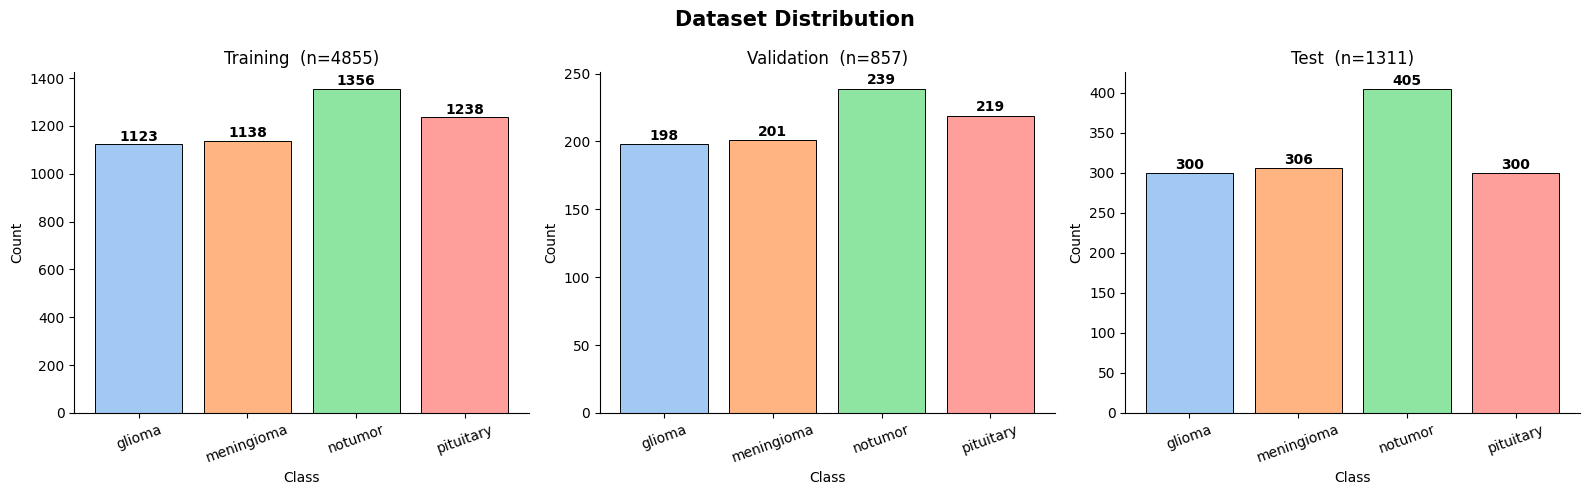

In [ ]:
def plot_dataset_distribution():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Dataset Distribution", fontsize=15, fontweight='bold')

    splits = {
        "Training":   Counter(targets[train_indices]),
        "Validation": Counter(targets[val_indices]),
        "Test":       Counter(np.array(test_dataset.targets)),
    }
    colors = sns.color_palette("pastel", num_classes)

    for ax, (split_name, counts) in zip(axes, splits.items()):
        labels  = [class_names[i] for i in sorted(counts)]
        values  = [counts[i]      for i in sorted(counts)]
        bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7)

        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_title(f"{split_name}  (n={sum(values)})", fontsize=12)
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=20)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/plots/dataset_distribution.png", dpi=150)
    plt.show()

os.makedirs("/content/drive/MyDrive/plots", exist_ok=True)
plot_dataset_distribution()

In [ ]:
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=num_classes,
    output_attentions=True
).to(device)

mit_model = SegformerForImageClassification.from_pretrained(
    "nvidia/mit-b2",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
).to(device)

# Freeze backbones initially (progressive unfreezing later)
for p in vit_model.vit.parameters():
    p.requires_grad = False
for p in mit_model.segformer.parameters():
    p.requires_grad = False

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/366 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

SegformerForImageClassification LOAD REPORT from: nvidia/mit-b2
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 512]) vs model:torch.Size([4, 512])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

vit_optimizer = AdamW([
    {"params": [p for n,p in vit_model.named_parameters() if "vit"       in n], "lr": 1e-5},
    {"params": [p for n,p in vit_model.named_parameters() if "vit" not   in n], "lr": 3e-4},
], weight_decay=0.01)

mit_optimizer = AdamW([
    {"params": [p for n,p in mit_model.named_parameters() if "segformer"     in n], "lr": 1e-5},
    {"params": [p for n,p in mit_model.named_parameters() if "segformer" not in n], "lr": 3e-4},
], weight_decay=0.01)

total_steps   = len(train_loader) * epochs
vit_scheduler = get_cosine_schedule_with_warmup(vit_optimizer, int(0.1*total_steps), total_steps)
mit_scheduler = get_cosine_schedule_with_warmup(mit_optimizer, int(0.1*total_steps), total_steps)

use_amp = device.type == "cuda"
scaler  = GradScaler(enabled=use_amp)

In [ ]:
# FIXED HELPER FUNCTIONS (SELF-CONTAINED - NO GLOBAL VARS)
def mixup_data(x, y, alpha=0.15):
    lam = np.random.beta(alpha, alpha)
    device = x.device
    index = torch.randperm(x.size(0)).to(device)
    return lam*x + (1-lam)*x[index], y, y[index], lam

def unfreeze_backbone(model, attr):
    for p in getattr(model, attr).parameters():
        p.requires_grad = True

def tta_forward(model, imgs, TTA_TEMP=1.3):
    device = imgs.device
    augments = [imgs, torch.flip(imgs, [3])]
    probs = []
    for aug in augments:
        logits = model(aug).logits / TTA_TEMP
        probs.append(F.softmax(logits, dim=1))
    return torch.stack(probs).mean(0)

def evaluate(model, loader):
    device = next(model.parameters()).device
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            preds = tta_forward(model, imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_epoch(model, loader, optimizer, scheduler):
    device = next(model.parameters()).device
    model.train()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = GradScaler()
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        imgs_mix, ya, yb, lam = mixup_data(imgs, labels)

        optimizer.zero_grad()
        with autocast(device_type='cuda', enabled=True):
            logits = model(imgs_mix).logits
            loss = lam * criterion(logits, ya) + (1-lam) * criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)

print("✅ FIXED HELPERS READY - NO GLOBAL VARIABLES!")


✅ FIXED HELPERS READY - NO GLOBAL VARIABLES!


In [ ]:
def train_full_model(model, optimizer, scheduler, attr, name):
    best_acc   = -1
    best_state = copy.deepcopy(model.state_dict())

    history = {"train_loss": [], "val_acc": []}  # ← NEW

    for epoch in range(epochs):

        if epoch == 3:
            print(f"  [{name}] Backbone unfrozen at epoch {epoch+1}")
            unfreeze_backbone(model, attr)
            for g in optimizer.param_groups:
                g["lr"] *= 0.3

        loss    = train_epoch(model, train_loader, optimizer, scheduler)
        val_acc = evaluate(model, val_loader)

        history["train_loss"].append(loss)
        history["val_acc"].append(val_acc)

        print(f"{name} | Epoch {epoch+1:02d}/{epochs} | Loss {loss:.4f} | Val {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f"{name} Best Val Acc: {best_acc:.4f}\n")
    return model, history


print("=" * 50)
print("Training ViT")
vit_model, vit_history = train_full_model(vit_model, vit_optimizer, vit_scheduler, "vit",       "ViT")

print("=" * 50)
print("Training MiT-B2")
mit_model, mit_history = train_full_model(mit_model, mit_optimizer, mit_scheduler, "segformer", "MiT")

Training ViT
ViT | Epoch 01/15 | Loss 1.3137 | Val 0.5589
ViT | Epoch 02/15 | Loss 1.0954 | Val 0.7363
ViT | Epoch 03/15 | Loss 0.9811 | Val 0.7305
  [ViT] Backbone unfrozen at epoch 4
ViT | Epoch 04/15 | Loss 0.6632 | Val 0.9405
ViT | Epoch 05/15 | Loss 0.5680 | Val 0.9673
ViT | Epoch 06/15 | Loss 0.5472 | Val 0.9592
ViT | Epoch 07/15 | Loss 0.5161 | Val 0.9755
ViT | Epoch 08/15 | Loss 0.5204 | Val 0.9872
ViT | Epoch 09/15 | Loss 0.4914 | Val 0.9825
ViT | Epoch 10/15 | Loss 0.4868 | Val 0.9837
ViT | Epoch 11/15 | Loss 0.4911 | Val 0.9848
ViT | Epoch 12/15 | Loss 0.4847 | Val 0.9837
ViT | Epoch 13/15 | Loss 0.4708 | Val 0.9825
ViT | Epoch 14/15 | Loss 0.4775 | Val 0.9848
ViT | Epoch 15/15 | Loss 0.4949 | Val 0.9848
ViT Best Val Acc: 0.9872

Training MiT-B2
MiT | Epoch 01/15 | Loss 1.2926 | Val 0.7001
MiT | Epoch 02/15 | Loss 0.9788 | Val 0.7946
MiT | Epoch 03/15 | Loss 0.8454 | Val 0.8635
  [MiT] Backbone unfrozen at epoch 4
MiT | Epoch 04/15 | Loss 0.6975 | Val 0.9300
MiT | Epoch 05/1

In [ ]:
def train_full_model_cv(model, train_loader_cv, val_loader_cv,
                        optimizer, scheduler, attr, name, epochs_cv=15):
    best_acc = -1
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs_cv):
        if epoch == 3:
            print(f"  [{name}] Backbone unfrozen at epoch {epoch+1}")
            unfreeze_backbone(model, attr)
            for g in optimizer.param_groups:
                g["lr"] *= 0.3

        loss = train_epoch(model, train_loader_cv, optimizer, scheduler)
        val_acc = evaluate(model, val_loader_cv)
        print(f"{name} | Epoch {epoch+1:02d}/{epochs_cv} | Loss {loss:.4f} | Val {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f"{name} Best Val Acc: {best_acc:.4f}\n")
    return model, {}, best_acc

print("✅ TRAINING FUNCTION READY!")


✅ TRAINING FUNCTION READY!


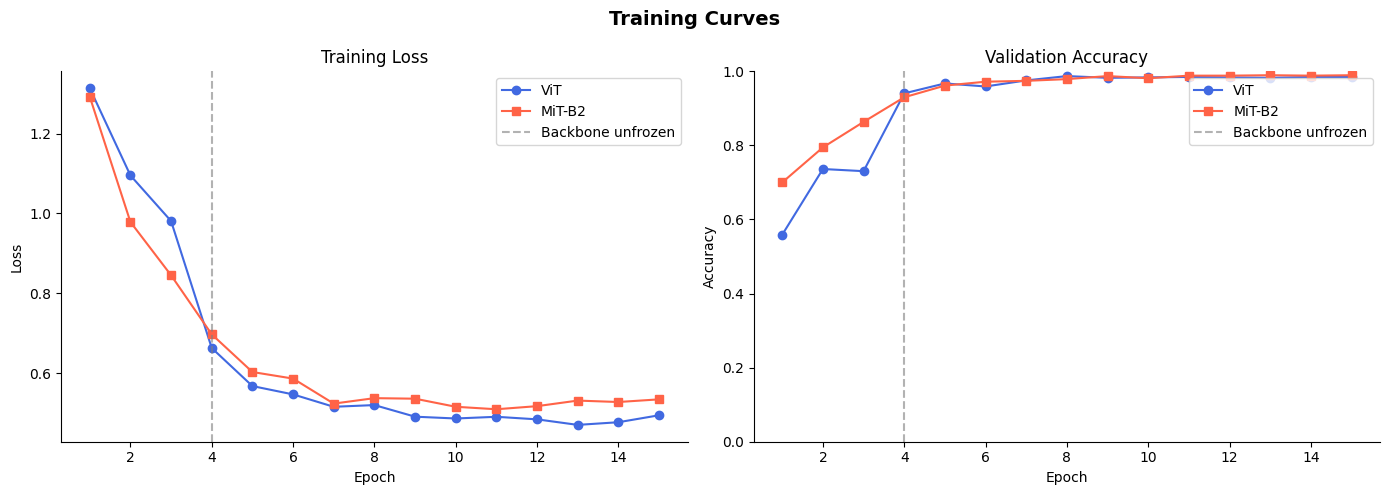

In [ ]:
def plot_training_curves(vit_hist, mit_hist):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves", fontsize=14, fontweight='bold')
    ep = range(1, epochs + 1)

    # Loss
    axes[0].plot(ep, vit_hist["train_loss"], 'o-', label='ViT',    color='royalblue')
    axes[0].plot(ep, mit_hist["train_loss"], 's-', label='MiT-B2', color='tomato')
    axes[0].axvline(4, color='gray', linestyle='--', alpha=0.6, label='Backbone unfrozen')
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); sns.despine(ax=axes[0])

    # Val Accuracy
    axes[1].plot(ep, vit_hist["val_acc"], 'o-', label='ViT',    color='royalblue')
    axes[1].plot(ep, mit_hist["val_acc"], 's-', label='MiT-B2', color='tomato')
    axes[1].axvline(4, color='gray', linestyle='--', alpha=0.6, label='Backbone unfrozen')
    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1); axes[1].legend(); sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/plots/training_curves.png", dpi=150)
    plt.show()

plot_training_curves(vit_history, mit_history)

In [ ]:
def ensemble_predict(loader=test_loader):
    vit_model.eval(); mit_model.eval()
    preds_all, labels_all, probs_all = [], [], []
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            v = tta_forward(vit_model, imgs)
            m = tta_forward(mit_model, imgs)

            # Confidence-weighted ensemble
            alpha = v.max(1)[0] / (v.max(1)[0] + m.max(1)[0] + 1e-8)
            probs = alpha.unsqueeze(1)*v + (1 - alpha).unsqueeze(1)*m

            preds  = probs.argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    return correct/total, preds_all, labels_all, np.array(probs_all)


vit_acc = evaluate(vit_model, test_loader)
mit_acc = evaluate(mit_model, test_loader)
ens_acc, preds, labels, probs_all = ensemble_predict()

print(f"ViT Accuracy:      {vit_acc:.4f}")
print(f"MiT-B2 Accuracy:   {mit_acc:.4f}")
print(f"Ensemble Accuracy: {ens_acc:.4f}")

ViT Accuracy:      0.9886
MiT-B2 Accuracy:   0.9878
Ensemble Accuracy: 0.9901


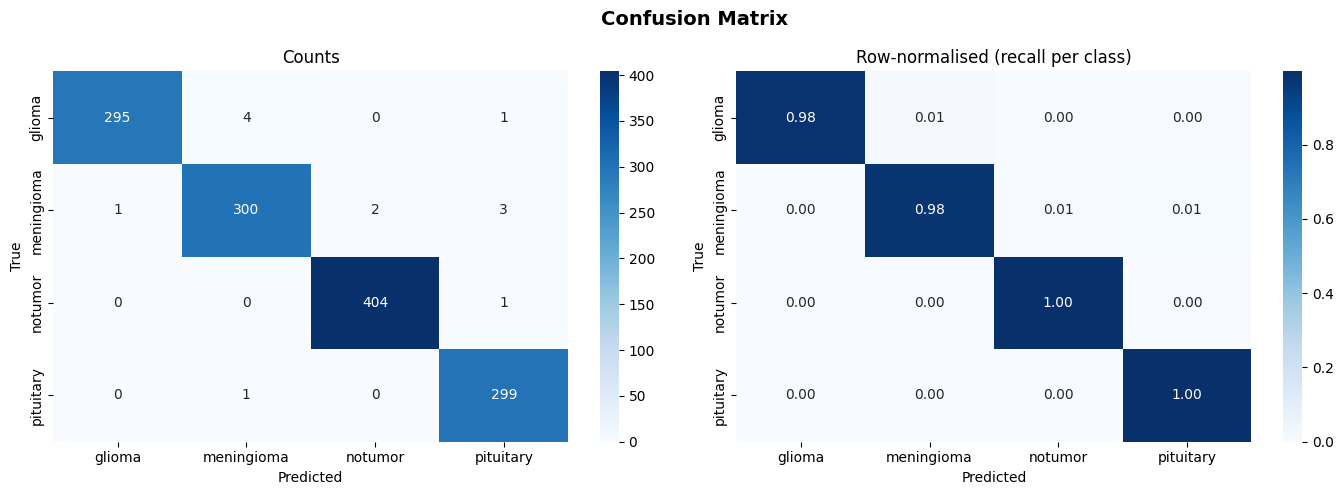


Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       300
  meningioma       0.98      0.98      0.98       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.98      1.00      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



In [ ]:
def plot_confusion_matrix(labels, preds, class_names):
    cm  = confusion_matrix(labels, preds)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised %

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrix", fontsize=14, fontweight='bold')

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    # Normalised
    sns.heatmap(pct, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("Row-normalised (recall per class)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/plots/confusion_matrix.png", dpi=150)
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(labels, preds, target_names=class_names))

plot_confusion_matrix(labels, preds, class_names)

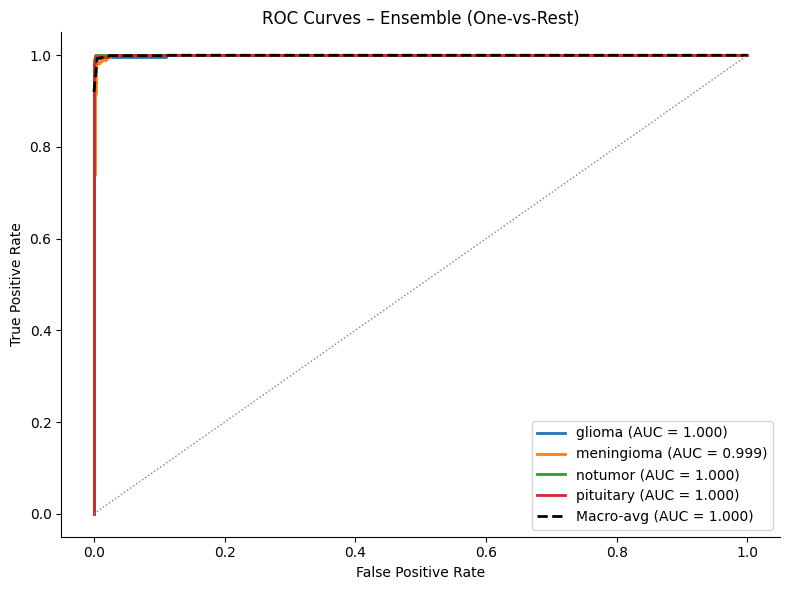

In [ ]:
def plot_roc_curves(labels, probs_all, class_names):
    y_bin = label_binarize(labels, classes=list(range(num_classes)))
    colors = sns.color_palette("tab10", num_classes)

    plt.figure(figsize=(8, 6))

    for i, (cls, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs_all[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")

    # Macro-average
    fpr_grid  = np.linspace(0, 1, 200)
    tpr_interp = []
    for i in range(num_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs_all[:, i])
        tpr_interp.append(np.interp(fpr_grid, fpr_i, tpr_i))
    mean_tpr = np.mean(tpr_interp, axis=0)
    plt.plot(fpr_grid, mean_tpr, 'k--', lw=2,
             label=f"Macro-avg (AUC = {auc(fpr_grid, mean_tpr):.3f})")

    plt.plot([0,1],[0,1], 'gray', linestyle=':', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves – Ensemble (One-vs-Rest)")
    plt.legend(loc="lower right")
    sns.despine()
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/plots/roc_curves.png", dpi=150)
    plt.show()

plot_roc_curves(labels, probs_all, class_names)

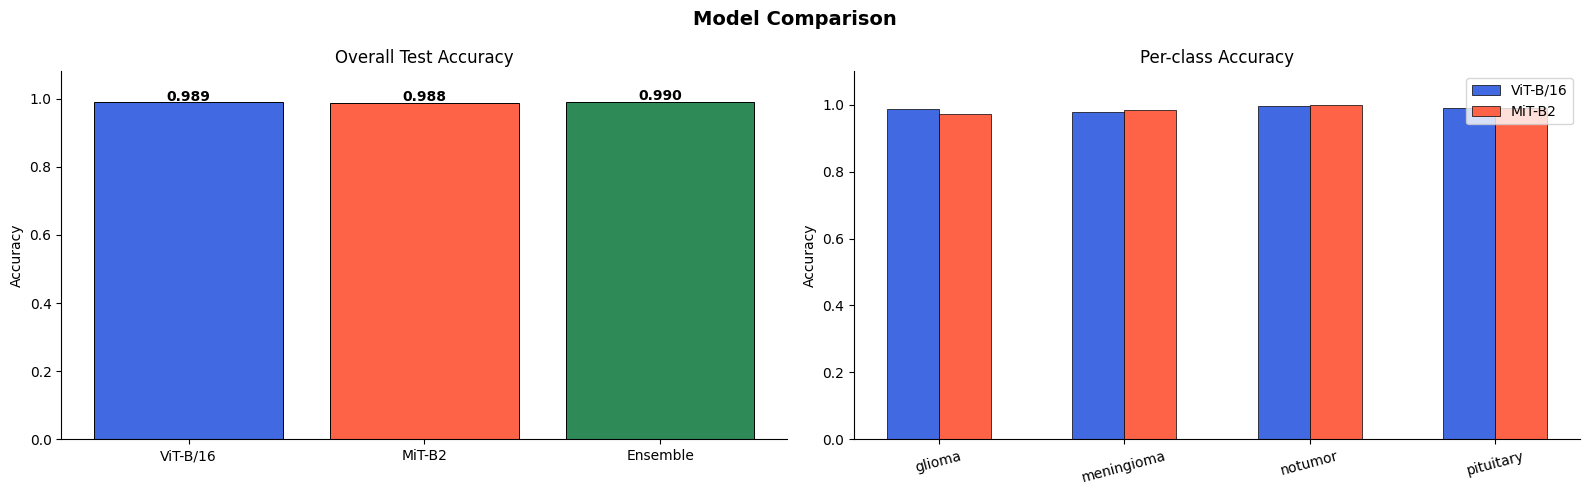

In [ ]:
def plot_model_comparison(vit_acc, mit_acc, ens_acc):
    # Per-class accuracy for each model
    def per_class_acc(model):
        model.eval()
        correct = np.zeros(num_classes)
        totals  = np.zeros(num_classes)
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = tta_forward(model, imgs).argmax(1)
                for c in range(num_classes):
                    mask = lbls == c
                    correct[c] += (preds[mask] == c).sum().item()
                    totals[c]  += mask.sum().item()
        return correct / (totals + 1e-8)

    vit_pc  = per_class_acc(vit_model)
    mit_pc  = per_class_acc(mit_model)

    x   = np.arange(num_classes)
    w   = 0.28
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Model Comparison", fontsize=14, fontweight='bold')

    # Overall accuracy
    names  = ["ViT-B/16", "MiT-B2", "Ensemble"]
    accs   = [vit_acc, mit_acc, ens_acc]
    colors = ["royalblue", "tomato", "seagreen"]
    bars   = axes[0].bar(names, accs, color=colors, edgecolor='black', linewidth=0.7)
    for bar, a in zip(bars, accs):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{a:.3f}", ha='center', fontweight='bold')
    axes[0].set_ylim(0, 1.08)
    axes[0].set_title("Overall Test Accuracy")
    axes[0].set_ylabel("Accuracy")
    sns.despine(ax=axes[0])

    # Per-class accuracy
    axes[1].bar(x - w, vit_pc,  w, label='ViT-B/16', color='royalblue', edgecolor='black', lw=0.5)
    axes[1].bar(x,     mit_pc,  w, label='MiT-B2',   color='tomato',    edgecolor='black', lw=0.5)
    axes[1].set_xticks(x - w/2)
    axes[1].set_xticklabels(class_names, rotation=15)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title("Per-class Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/plots/model_comparison.png", dpi=150)
    plt.show()

plot_model_comparison(vit_acc, mit_acc, ens_acc)

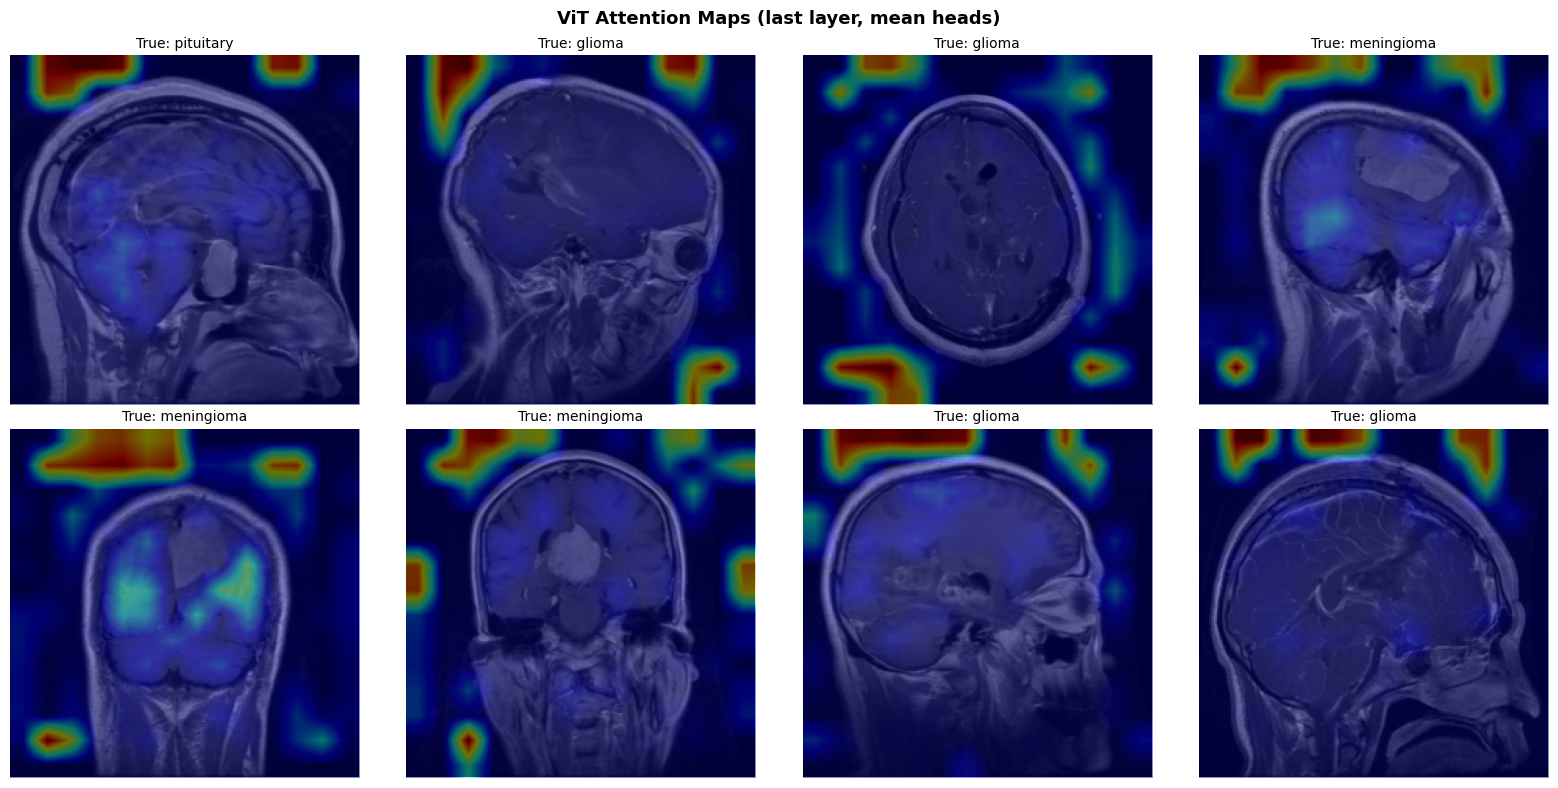

In [ ]:
def denormalize(img_tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(processor.image_mean).view(3,1,1)
    std  = torch.tensor(processor.image_std).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)


def visualize_attention_grid(model, dataset, n=8, save_path=None):
    """
    Show n random test images with their ViT attention overlays.
    Displays the mean attention from the last layer, CLS → patch tokens.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    cols    = 4
    rows    = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for ax_idx, sample_idx in enumerate(indices):
        img, label = dataset[sample_idx]
        ax = axes[ax_idx]

        with torch.no_grad():
            out  = model(img.unsqueeze(0).to(device))
            attn = out.attentions[-1][0]          # (heads, seq, seq)
            attn = attn[:, 0, 1:].mean(0)         # (num_patches,)
            side = int(attn.shape[0] ** 0.5)      # 14 for ViT-B/16
            attn = attn.reshape(side, side).cpu().numpy()
            attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

        display_img = denormalize(img).permute(1, 2, 0).numpy()
        ax.imshow(display_img)
        ax.imshow(attn, alpha=0.45, cmap='jet',
                  extent=(0, image_size, image_size, 0),
                  interpolation='bilinear')
        ax.set_title(f"True: {class_names[label]}", fontsize=10)
        ax.axis('off')

    # Hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle("ViT Attention Maps (last layer, mean heads)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


visualize_attention_grid(
    vit_model, test_dataset, n=8,
    save_path="/content/drive/MyDrive/plots/attention_maps.png"
)

In [ ]:
os.makedirs("/content/drive/MyDrive/final_vit", exist_ok=True)
os.makedirs("/content/drive/MyDrive/final_mit", exist_ok=True)

vit_model.save_pretrained("/content/drive/MyDrive/final_vit")
mit_model.save_pretrained("/content/drive/MyDrive/final_mit")
processor.save_pretrained("/content/drive/MyDrive/final_vit")

print("All models and plots saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models and plots saved.


In [ ]:
def run_cross_validation_complete(k_folds=3, model_type="vit"):
    train_dir = "/content/drive/MyDrive/MRI-dataset/Training"
    image_size, batch_size = 224, 16

    processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(8),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize(processor.image_mean, processor.image_std)
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(processor.image_mean, processor.image_std)
    ])

    print("Loading training data for CV...")
    base_dataset_temp = datasets.ImageFolder(train_dir)
    targets_cv = np.array(base_dataset_temp.targets)
    num_classes_cv = len(base_dataset_temp.classes)
    print(f"Found {len(targets_cv)} images, {num_classes_cv} classes")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_idx_cv, val_idx_cv) in enumerate(skf.split(np.zeros(len(targets_cv)), targets_cv), 1):
        print(f"\n{'='*50}")
        print(f"{model_type.upper()} | Fold {fold}/{k_folds}")
        print(f"{'='*50}")

        train_dataset_cv = Subset(datasets.ImageFolder(train_dir, transform=train_transform), train_idx_cv)
        val_dataset_cv = Subset(datasets.ImageFolder(train_dir, transform=eval_transform), val_idx_cv)

        train_loader_cv = DataLoader(train_dataset_cv, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader_cv = DataLoader(val_dataset_cv, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

        if model_type == "vit":
            model = ViTForImageClassification.from_pretrained(
                "google/vit-base-patch16-224-in21k", num_labels=num_classes_cv, output_attentions=True
            ).to(device)
            for p in model.vit.parameters(): p.requires_grad = False
            optimizer = AdamW([{"params": [p for n,p in model.named_parameters() if "vit" in n], "lr": 1e-5},
                              {"params": [p for n,p in model.named_parameters() if "vit" not in n], "lr": 3e-4}], weight_decay=0.01)
            backbone_attr = "vit"
        else:
            model = SegformerForImageClassification.from_pretrained(
                "nvidia/mit-b2", num_labels=num_classes_cv, ignore_mismatched_sizes=True
            ).to(device)
            for p in model.segformer.parameters(): p.requires_grad = False
            optimizer = AdamW([{"params": [p for n,p in model.named_parameters() if "segformer" in n], "lr": 1e-5},
                              {"params": [p for n,p in model.named_parameters() if "segformer" not in n], "lr": 3e-4}], weight_decay=0.01)
            backbone_attr = "segformer"

        total_steps_cv = len(train_loader_cv) * 15
        scheduler_cv = get_cosine_schedule_with_warmup(optimizer, int(0.1*total_steps_cv), total_steps_cv)

        model, hist_cv, best_val = train_full_model_cv(
            model, train_loader_cv, val_loader_cv, optimizer, scheduler_cv,
            attr=backbone_attr, name=f"{model_type.upper()}-Fold-{fold}"
        )
        fold_accuracies.append(best_val)

    print("\n" + "#"*70)
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f"🎯 {model_type.upper()} {k_folds}-FOLD CV: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"📄 PAPER TEXT: '{k_folds}-fold CV: {model_type.upper()} {mean_acc*100:.1f}±{std_acc*100:.1f}% confirms result stability'")
    print("#"*70)
    return fold_accuracies

# START TRAINING (25 minutes)
vit_cv_results = run_cross_validation_complete(k_folds=3, model_type="vit")


Loading training data for CV...
Found 5712 images, 4 classes
Using device: cuda

VIT | Fold 1/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-1 | Epoch 01/15 | Loss 1.3405 | Val 0.5557
VIT-Fold-1 | Epoch 02/15 | Loss 1.1344 | Val 0.6486
VIT-Fold-1 | Epoch 03/15 | Loss 1.0119 | Val 0.6623
  [VIT-Fold-1] Backbone unfrozen at epoch 4
VIT-Fold-1 | Epoch 04/15 | Loss 0.6888 | Val 0.9527
VIT-Fold-1 | Epoch 05/15 | Loss 0.5941 | Val 0.9611
VIT-Fold-1 | Epoch 06/15 | Loss 0.5598 | Val 0.9737
VIT-Fold-1 | Epoch 07/15 | Loss 0.5374 | Val 0.9779
VIT-Fold-1 | Epoch 08/15 | Loss 0.5173 | Val 0.9821
VIT-Fold-1 | Epoch 09/15 | Loss 0.5147 | Val 0.9827
VIT-Fold-1 | Epoch 10/15 | Loss 0.4908 | Val 0.9832
VIT-Fold-1 | Epoch 11/15 | Loss 0.5029 | Val 0.9832
VIT-Fold-1 | Epoch 12/15 | Loss 0.5053 | Val 0.9816
VIT-Fold-1 | Epoch 13/15 | Loss 0.4922 | Val 0.9816
VIT-Fold-1 | Epoch 14/15 | Loss 0.4910 | Val 0.9816
VIT-Fold-1 | Epoch 15/15 | Loss 0.5067 | Val 0.9821
VIT-Fold-1 Best Val Acc: 0.9832


VIT | Fold 2/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-2 | Epoch 01/15 | Loss 1.3360 | Val 0.5247
VIT-Fold-2 | Epoch 02/15 | Loss 1.1426 | Val 0.6980
VIT-Fold-2 | Epoch 03/15 | Loss 1.0135 | Val 0.7290
  [VIT-Fold-2] Backbone unfrozen at epoch 4
VIT-Fold-2 | Epoch 04/15 | Loss 0.6936 | Val 0.9228
VIT-Fold-2 | Epoch 05/15 | Loss 0.5662 | Val 0.9601
VIT-Fold-2 | Epoch 06/15 | Loss 0.5374 | Val 0.9606
VIT-Fold-2 | Epoch 07/15 | Loss 0.5203 | Val 0.9674
VIT-Fold-2 | Epoch 08/15 | Loss 0.5096 | Val 0.9806
VIT-Fold-2 | Epoch 09/15 | Loss 0.4886 | Val 0.9816
VIT-Fold-2 | Epoch 10/15 | Loss 0.4969 | Val 0.9806
VIT-Fold-2 | Epoch 11/15 | Loss 0.4994 | Val 0.9811
VIT-Fold-2 | Epoch 12/15 | Loss 0.5105 | Val 0.9848
VIT-Fold-2 | Epoch 13/15 | Loss 0.4975 | Val 0.9832
VIT-Fold-2 | Epoch 14/15 | Loss 0.4796 | Val 0.9832
VIT-Fold-2 | Epoch 15/15 | Loss 0.5005 | Val 0.9837
VIT-Fold-2 Best Val Acc: 0.9848


VIT | Fold 3/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-3 | Epoch 01/15 | Loss 1.3326 | Val 0.5672
VIT-Fold-3 | Epoch 02/15 | Loss 1.1540 | Val 0.7264
VIT-Fold-3 | Epoch 03/15 | Loss 1.0238 | Val 0.6528
  [VIT-Fold-3] Backbone unfrozen at epoch 4
VIT-Fold-3 | Epoch 04/15 | Loss 0.6942 | Val 0.9370
VIT-Fold-3 | Epoch 05/15 | Loss 0.5676 | Val 0.9664
VIT-Fold-3 | Epoch 06/15 | Loss 0.5721 | Val 0.9737
VIT-Fold-3 | Epoch 07/15 | Loss 0.5581 | Val 0.9706
VIT-Fold-3 | Epoch 08/15 | Loss 0.5079 | Val 0.9722
VIT-Fold-3 | Epoch 09/15 | Loss 0.4903 | Val 0.9764
VIT-Fold-3 | Epoch 10/15 | Loss 0.5262 | Val 0.9779
VIT-Fold-3 | Epoch 11/15 | Loss 0.4712 | Val 0.9764
VIT-Fold-3 | Epoch 12/15 | Loss 0.4975 | Val 0.9753
VIT-Fold-3 | Epoch 13/15 | Loss 0.4919 | Val 0.9785
VIT-Fold-3 | Epoch 14/15 | Loss 0.5145 | Val 0.9774
VIT-Fold-3 | Epoch 15/15 | Loss 0.4924 | Val 0.9774
VIT-Fold-3 Best Val Acc: 0.9785


######################################################################
🎯 VIT 3-FOLD CV: 0.9821 ± 0.0027
📄 PAPER TEXT: '3-fold CV: VIT 98.2±0.3

In [ ]:
vit_cv_results = run_cross_validation_complete(k_folds=3, model_type="vit")


Loading training data for CV...
Found 5712 images, 4 classes
Using device: cuda

VIT | Fold 1/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-1 | Epoch 01/15 | Loss 1.3465 | Val 0.5562
VIT-Fold-1 | Epoch 02/15 | Loss 1.1440 | Val 0.6502
VIT-Fold-1 | Epoch 03/15 | Loss 1.0116 | Val 0.6970
  [VIT-Fold-1] Backbone unfrozen at epoch 4
VIT-Fold-1 | Epoch 04/15 | Loss 0.7088 | Val 0.9233
VIT-Fold-1 | Epoch 05/15 | Loss 0.5972 | Val 0.9585
VIT-Fold-1 | Epoch 06/15 | Loss 0.5263 | Val 0.9690
VIT-Fold-1 | Epoch 07/15 | Loss 0.5144 | Val 0.9785
VIT-Fold-1 | Epoch 08/15 | Loss 0.5303 | Val 0.9806
VIT-Fold-1 | Epoch 09/15 | Loss 0.5158 | Val 0.9795
VIT-Fold-1 | Epoch 10/15 | Loss 0.4811 | Val 0.9832
VIT-Fold-1 | Epoch 11/15 | Loss 0.4889 | Val 0.9816
VIT-Fold-1 | Epoch 12/15 | Loss 0.4895 | Val 0.9832
VIT-Fold-1 | Epoch 13/15 | Loss 0.5008 | Val 0.9806
VIT-Fold-1 | Epoch 14/15 | Loss 0.5090 | Val 0.9816
VIT-Fold-1 | Epoch 15/15 | Loss 0.5037 | Val 0.9816
VIT-Fold-1 Best Val Acc: 0.9832


VIT | Fold 2/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-2 | Epoch 01/15 | Loss 1.3153 | Val 0.5678
VIT-Fold-2 | Epoch 02/15 | Loss 1.1265 | Val 0.6775
VIT-Fold-2 | Epoch 03/15 | Loss 1.0079 | Val 0.6870
  [VIT-Fold-2] Backbone unfrozen at epoch 4
VIT-Fold-2 | Epoch 04/15 | Loss 0.6684 | Val 0.9370
VIT-Fold-2 | Epoch 05/15 | Loss 0.5831 | Val 0.9569
VIT-Fold-2 | Epoch 06/15 | Loss 0.5609 | Val 0.9716
VIT-Fold-2 | Epoch 07/15 | Loss 0.5194 | Val 0.9800
VIT-Fold-2 | Epoch 08/15 | Loss 0.5145 | Val 0.9774
VIT-Fold-2 | Epoch 09/15 | Loss 0.5084 | Val 0.9774
VIT-Fold-2 | Epoch 10/15 | Loss 0.5261 | Val 0.9743
VIT-Fold-2 | Epoch 11/15 | Loss 0.4905 | Val 0.9806
VIT-Fold-2 | Epoch 12/15 | Loss 0.5284 | Val 0.9816
VIT-Fold-2 | Epoch 13/15 | Loss 0.5018 | Val 0.9832
VIT-Fold-2 | Epoch 14/15 | Loss 0.5233 | Val 0.9821
VIT-Fold-2 | Epoch 15/15 | Loss 0.4695 | Val 0.9827
VIT-Fold-2 Best Val Acc: 0.9832


VIT | Fold 3/3


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VIT-Fold-3 | Epoch 01/15 | Loss 1.3198 | Val 0.5620
VIT-Fold-3 | Epoch 02/15 | Loss 1.1339 | Val 0.6282
VIT-Fold-3 | Epoch 03/15 | Loss 1.0087 | Val 0.7148
  [VIT-Fold-3] Backbone unfrozen at epoch 4
VIT-Fold-3 | Epoch 04/15 | Loss 0.6883 | Val 0.9375
VIT-Fold-3 | Epoch 05/15 | Loss 0.5674 | Val 0.9617
VIT-Fold-3 | Epoch 06/15 | Loss 0.5495 | Val 0.9617
VIT-Fold-3 | Epoch 07/15 | Loss 0.5177 | Val 0.9727
VIT-Fold-3 | Epoch 08/15 | Loss 0.5029 | Val 0.9785
VIT-Fold-3 | Epoch 09/15 | Loss 0.5169 | Val 0.9827
VIT-Fold-3 | Epoch 10/15 | Loss 0.5140 | Val 0.9790
VIT-Fold-3 | Epoch 11/15 | Loss 0.4957 | Val 0.9795
VIT-Fold-3 | Epoch 12/15 | Loss 0.4808 | Val 0.9790
VIT-Fold-3 | Epoch 13/15 | Loss 0.5003 | Val 0.9827
VIT-Fold-3 | Epoch 14/15 | Loss 0.4978 | Val 0.9811
VIT-Fold-3 | Epoch 15/15 | Loss 0.4986 | Val 0.9821
VIT-Fold-3 Best Val Acc: 0.9827


######################################################################
🎯 VIT 3-FOLD CV: 0.9830 ± 0.0002
📄 PAPER TEXT: '3-fold CV: VIT 98.3±0.0

<>:29: SyntaxWarning: invalid escape sequence '\%'
<>:29: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_787/443618417.py:29: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('Validation Accuracy (\%)')


Saved.


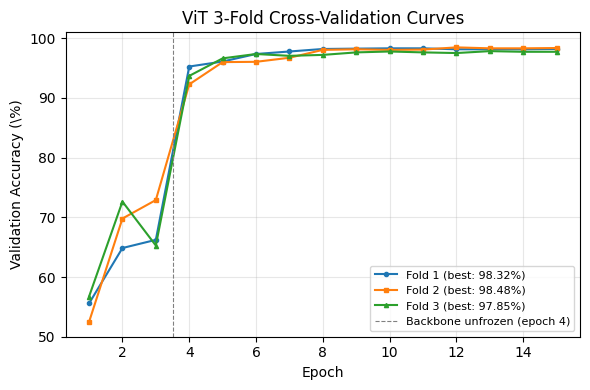

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 16)

# Run 2 per-epoch validation accuracies
fold1 = [0.5557,0.6486,0.6623,0.9527,0.9611,0.9737,
         0.9779,0.9821,0.9827,0.9832,0.9832,0.9816,
         0.9816,0.9816,0.9821]

fold2 = [0.5247,0.6980,0.7290,0.9228,0.9601,0.9606,
         0.9674,0.9806,0.9816,0.9806,0.9811,0.9848,
         0.9832,0.9832,0.9837]

fold3 = [0.5672,0.7264,0.6528,0.9370,0.9664,0.9737,
         0.9706,0.9722,0.9764,0.9779,0.9764,0.9753,
         0.9785,0.9774,0.9774]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, [v*100 for v in fold1],
        marker='o', markersize=3, label='Fold 1 (best: 98.32%)')
ax.plot(epochs, [v*100 for v in fold2],
        marker='s', markersize=3, label='Fold 2 (best: 98.48%)')
ax.plot(epochs, [v*100 for v in fold3],
        marker='^', markersize=3, label='Fold 3 (best: 97.85%)')
ax.axvline(x=3.5, color='gray', linestyle='--',
           linewidth=0.8, label='Backbone unfrozen (epoch 4)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (\%)')
ax.set_title('ViT 3-Fold Cross-Validation Curves')
ax.set_ylim(50, 101)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_curves.pdf', dpi=300, bbox_inches='tight')
plt.savefig('cv_curves.png', dpi=300, bbox_inches='tight')
print("Saved.")